In [1]:
# import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import random

In [2]:
from google.colab import files
files.upload()

Saving ElectricityDemandDataset.csv to ElectricityDemandDataset.csv


{'ElectricityDemandDataset.csv': b'Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand\r\n01-Jan-20,0,2,1,2020,1,3,61.28895133,2457.119872\r\n01-Jan-20,1,2,1,2020,1,3,52.87370188,2269.904712\r\n01-Jan-20,2,2,1,2020,1,4.244481524,36.34178252,2215.640403\r\n01-Jan-20,3,2,1,2020,1,3,72.62937755,2174.232413\r\n01-Jan-20,4,2,1,2020,1,3.881207759,90.58244351,2472.453006\r\n01-Jan-20,5,2,1,2020,1,10.82257105,67.75343321,3104.845505\r\n01-Jan-20,6,2,1,2020,1,6.306673322,94.91259116,3759.476912\r\n01-Jan-20,7,2,1,2020,1,7.464640228,74.45685967,4114.486001\r\n01-Jan-20,8,2,1,2020,1,14.74687644,66.72500515,4575.159503\r\n01-Jan-20,9,2,1,2020,1,19.73825392,55.03616034,4512.169696\r\n01-Jan-20,10,2,1,2020,1,21.44724451,69.31796175,4622.245785\r\n01-Jan-20,11,2,1,2020,1,18.28490594,56.4143475,4240.094906\r\n01-Jan-20,12,2,1,2020,1,20.21957278,48.9417152,4439.2403\r\n01-Jan-20,13,2,1,2020,1,20.30584508,70.65464651,4758.538052\r\n01-Jan-20,14,2,1,2020,1,14.87428435,55.95688534,44

In [3]:
data = pd.read_csv("ElectricityDemandDataset.csv")

In [4]:
data

,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
0,01-Jan-20,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
1,01-Jan-20,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2,01-Jan-20,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
3,01-Jan-20,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
4,01-Jan-20,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
43843,31-Dec-24,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
43844,31-Dec-24,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
43845,31-Dec-24,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957
43846,31-Dec-24,22.0,1.0,12.0,2024.0,366.0,3.000000,51.998107,3353.241682


In [5]:
# Check some basic information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    43848 non-null  object 
 1   hour         43837 non-null  float64
 2   dayofweek    43839 non-null  float64
 3   month        43840 non-null  float64
 4   year         43843 non-null  float64
 5   dayofyear    43843 non-null  float64
 6   Temperature  43841 non-null  float64
 7   Humidity     43838 non-null  float64
 8   Demand       43841 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.0+ MB


In [6]:
# Convert the 'Timestamp' column datatype to datetime format
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

/tmp/ipython-input-724726323.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Timestamp'] = pd.to_datetime(data['Timestamp'])


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Timestamp    43848 non-null  datetime64[ns]
 1   hour         43837 non-null  float64       
 2   dayofweek    43839 non-null  float64       
 3   month        43840 non-null  float64       
 4   year         43843 non-null  float64       
 5   dayofyear    43843 non-null  float64       
 6   Temperature  43841 non-null  float64       
 7   Humidity     43838 non-null  float64       
 8   Demand       43841 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 3.0 MB


In [8]:
# Set the 'Timestamp' column as DataFrame's index
data = data.set_index("Timestamp")

In [9]:
data

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [10]:
# Using Describe function to check the summary statistics
data[["Temperature","Humidity","Demand"]].describe()

,Temperature,Humidity,Demand
count,43841.000000,43838.000000,43841.000000
mean,25.067788,59.903007,5000.790976
std,12.821725,18.342604,1412.527409
min,3.000000,20.000000,1611.954020
25%,15.210186,46.241224,4015.668472
50%,25.003212,59.986720,5013.053367
75%,34.740971,73.796820,6000.803082
max,50.000000,95.000000,11910.705100


In [11]:
# Check for Missing Values

data.isnull().sum()

,0
hour,11
dayofweek,9
month,8
year,5
dayofyear,5
Temperature,7
Humidity,10
Demand,7


In [12]:
# To show the records that contain Any null values

data[data.isna().any(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-04-30,NaN,3.0,4.0,2020.0,121.0,21.820261,41.353675,5393.127681
2020-07-21,NaN,1.0,7.0,2020.0,203.0,36.555833,62.779665,6248.349423
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-27,NaN,5.0,2.0,2021.0,58.0,24.001003,53.303268,4523.253789
2021-12-13,23.0,0.0,12.0,2021.0,NaN,3.000000,75.457130,3225.225822
2021-12-14,NaN,1.0,12.0,2021.0,348.0,5.061319,47.215825,2887.848612


In [13]:
# To show the records that contain All null values

data[data.isna().all(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Drop those rows that contain All missing values

data = data.dropna(how = 'all')
data

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [15]:
# To show the records that contain All null values

data[data.isna().all(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,


In [16]:
# Check for Missing Values

data.isnull().sum()

,0
hour,7
dayofweek,5
month,4
year,1
dayofyear,1
Temperature,3
Humidity,6
Demand,3


Backward Fill - bfill

Forward Fill - ffill

In [17]:
# Applying 'ffill' method on columns

data[['hour', 'dayofweek', 'month', 'year', 'dayofyear']] = data[['hour', 'dayofweek', 'month', 'year', 'dayofyear']].ffill()

/tmp/ipython-input-210218051.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[['hour', 'dayofweek', 'month', 'year', 'dayofyear']] = data[['hour', 'dayofweek', 'month', 'year', 'dayofyear']].ffill()


Mantık: Eksik bir değeri, kendisinden bir önceki geçerli değerle doldurur.

Neden burada kullanıldı? Saat, gün, ay gibi zaman bileşenleri süreklidir. Eğer saat 14:00 ise ve bir sonraki satır boşsa, onun da 14:00 (veya yakın bir zaman) olduğu varsayılabilir. Bu veriler kategorik/sıralı olduğu için en yakın geçmişteki bilgiyi kopyalamak güvenlidir.

In [18]:
# Applying 'bfill' method on columns

data[['Temperature', 'Humidity']] = data[['Temperature', 'Humidity']].bfill()

/tmp/ipython-input-2691801141.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[['Temperature', 'Humidity']] = data[['Temperature', 'Humidity']].bfill()


Mantık: Eksik bir değeri, kendisinden bir sonraki geçerli değerle doldurur.

Neden burada kullanıldı? Sıcaklık ve nem gibi hava durumu verilerinde, bazen gelecekteki veriyi referans almak (özellikle veri setinin en başında boşluklar varsa) bir stratejidir. Ancak genellikle hava durumu için interpolate daha yaygındır; burada muhtemelen özel bir veri temizleme tercihi yapılmıştır.

In [19]:
# Applying 'interpolate' method on columns

data['Demand'] = data['Demand'].interpolate(method = 'time')

/tmp/ipython-input-1368912046.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Demand'] = data['Demand'].interpolate(method = 'time')


Mantık: İki bilinen nokta arasına düz bir çizgi çeker gibi ara değerleri hesaplar. method='time' parametresi, değerleri doldururken satırların arasındaki zaman farkına (index'in datetime olması gerekir) dikkat eder.

Neden burada kullanıldı? "Demand" (Talep) genellikle ani sıçramalar yapmayan, belirli bir trend izleyen sayısal bir veridir. Örneğin; saat 10:00'da talep 100, saat 12:00'de 200 ise; interpolasyon saat 11:00'deki boşluğu otomatik olarak 150 yaparak doldurur.


In [20]:
# Check for Missing Values

data.isnull().sum()

,0
hour,0
dayofweek,0
month,0
year,0
dayofyear,0
Temperature,0
Humidity,0
Demand,0


In [21]:
# Shape of dataframe

data.shape

(43844, 8)

In [22]:
data

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [23]:
# Create the 'Quarter' column at 5th index in the dataset
data.insert(5,"quarter",data.index.quarter)
data

,hour,dayofweek,month,year,dayofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,4,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,4,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,4,3.000000,40.565916,4015.979957


In [24]:
# Check some basic information about the dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43844 entries, 2020-01-01 to 2024-12-31
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43844 non-null  float64
 1   dayofweek    43844 non-null  float64
 2   month        43844 non-null  float64
 3   year         43844 non-null  float64
 4   dayofyear    43844 non-null  float64
 5   quarter      43844 non-null  int32  
 6   Temperature  43844 non-null  float64
 7   Humidity     43844 non-null  float64
 8   Demand       43844 non-null  float64
dtypes: float64(8), int32(1)
memory usage: 4.2 MB


In [25]:
# Convert the datatype from float to integer of columns

data[['hour', 'dayofweek', 'month','year', 'dayofyear']] = data[['hour', 'dayofweek', 'month','year', 'dayofyear']].astype(int)

/tmp/ipython-input-714536308.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[['hour', 'dayofweek', 'month','year', 'dayofyear']] = data[['hour', 'dayofweek', 'month','year', 'dayofyear']].astype(int)


In [26]:
# Check some basic information about the dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43844 entries, 2020-01-01 to 2024-12-31
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43844 non-null  int64  
 1   dayofweek    43844 non-null  int64  
 2   month        43844 non-null  int64  
 3   year         43844 non-null  int64  
 4   dayofyear    43844 non-null  int64  
 5   quarter      43844 non-null  int32  
 6   Temperature  43844 non-null  float64
 7   Humidity     43844 non-null  float64
 8   Demand       43844 non-null  float64
dtypes: float64(3), int32(1), int64(5)
memory usage: 4.2 MB


In [27]:
data

,hour,dayofweek,month,year,dayofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,4,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,4,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,4,3.000000,40.565916,4015.979957


In [28]:
# Create the 'Week of Year' column at 5th index in the dataset

data.insert(5, 'weekofyear', data.index.isocalendar().week.astype(int))
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,3.000000,40.565916,4015.979957


In [31]:
# Create a new column at 7th index to check the Weekend

data.insert(7, 'is_weekend', data.index.dayofweek.isin([5,6]))


ValueError: cannot insert is_weekend, already exists

In [32]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,False,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,False,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,False,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,False,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,False,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,False,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,False,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,False,3.000000,40.565916,4015.979957


In [33]:
#Convert the datatype from float to integer of the column

data['is_weekend'] = data['is_weekend'].astype(int)

/tmp/ipython-input-2314012127.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['is_weekend'] = data['is_weekend'].astype(int)


In [34]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957


In [35]:
# filtering the dataframe to get all records/rows where we have weekend

data[data['is_weekend'] == 1]

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-04,0,5,1,2020,4,1,1,1,3.000000,60.955363,2067.352696
2020-01-04,1,5,1,2020,4,1,1,1,3.000000,66.494073,2138.504702
2020-01-04,2,5,1,2020,4,1,1,1,3.000000,56.398199,1880.418696
2020-01-04,3,5,1,2020,4,1,1,1,4.474526,60.603500,2005.823854
2020-01-04,4,5,1,2020,4,1,1,1,7.738184,65.808825,2203.720413
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-29,19,6,12,2024,364,52,4,1,7.077721,46.341323,4304.049396
2024-12-29,20,6,12,2024,364,52,4,1,3.000000,69.641621,4146.583958
2024-12-29,21,6,12,2024,364,52,4,1,3.723222,46.751731,3366.641206


In [36]:
# import Holidays package

import holidays

In [37]:
# create a new column that will show holidays, otherwise NaN

data['Holidays'] = holidays.IN(years = data.year)

/tmp/ipython-input-2688841718.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Holidays'] = holidays.IN(years = data.year)


In [38]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Holidays
Timestamp,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872,NaN
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712,NaN
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403,NaN
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413,NaN
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,NaN
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,NaN
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,NaN


In [39]:
# using value_counts() to check the holidays with their count/occurance

data.Holidays.value_counts()

,count
Holidays,
Republic Day,120
Maha Shivaratri,120
Mahavir Jayanti,120
Good Friday,120
Buddha Purnima,120
Eid al-Fitr,120
Eid al-Adha,120
Janmashtami,120
Independence Day,120


In [40]:
# deleting the 'Holidays' column from the dataframe

data = data.drop('Holidays', axis=1)

In [41]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957


# Lagged Features: These are the past values of a time series data.

# Use - Past demand values are strong predictors. They can be used as input to predict future values.

In [42]:
# Create a new column that will contain Demand from the same hour yesterday

data['Demand_lag_24hr'] = data['Demand'].shift(24)

In [43]:
# Create a new column that will contain Demand from the same hour last week

data['demand_lag_168hr'] = data['Demand'].shift(168) # 24x7 = 168 hours for weekly shift

In [44]:
# show top rows of the dataframe

data.head(50)

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,demand_lag_168hr
Timestamp,,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872,NaN,NaN
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712,NaN,NaN
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403,NaN,NaN
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413,NaN,NaN
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006,NaN,NaN
2020-01-01,5,2,1,2020,1,1,1,0,10.822571,67.753433,3104.845505,NaN,NaN
2020-01-01,6,2,1,2020,1,1,1,0,6.306673,94.912591,3759.476912,NaN,NaN
2020-01-01,7,2,1,2020,1,1,1,0,7.464640,74.456860,4114.486001,NaN,NaN
2020-01-01,8,2,1,2020,1,1,1,0,14.746876,66.725005,4575.159503,NaN,NaN


In [50]:
# using iloc function for the slicing of dataframe' rows

data.iloc[160:200]

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-07,16,1,1,2020,7,2,1,0,14.016616,37.637752,4587.785143,4733.816549,NaN,3850.341646,967.346084
2020-01-07,17,1,1,2020,7,2,1,0,6.736632,54.734906,4833.704288,4796.039663,NaN,3851.911005,968.976208
2020-01-07,18,1,1,2020,7,2,1,0,17.782435,49.297649,5400.257796,4791.518998,NaN,3877.275122,1002.043933
2020-01-07,19,1,1,2020,7,2,1,0,3.000000,37.696671,4424.534926,4492.165854,NaN,3874.457166,1000.333186
2020-01-07,20,1,1,2020,7,2,1,0,7.116704,46.152197,4279.454320,4398.302015,NaN,3869.505179,997.918482
2020-01-07,21,1,1,2020,7,2,1,0,5.158936,44.385460,3768.807077,3705.698515,NaN,3872.134702,997.551162
2020-01-07,22,1,1,2020,7,2,1,0,3.000000,46.821530,2924.189540,3211.918549,NaN,3860.145994,1007.509986
2020-01-07,23,1,1,2020,7,2,1,0,3.000000,44.708096,2657.653050,2857.968639,NaN,3851.799511,1016.958689
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872,3857.890516,1007.130968


In [46]:
# Create a new column that will contain Rolling Mean of the Demand in last 24 hours

data['demand_rolling_mean_24hr'] = data['Demand'].rolling(window=24).mean()

In [47]:
# Create a new column that will contain Rolling Standard Deviation of the Demand in last 24 hours

data['demand_rolling_std_24hr'] = data['Demand'].rolling(window=24).std()

In [48]:
# show top rows of the dataframe

data.head(27)

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-01,0,2,1,2020,1,1,1,0,3.000000,61.288951,2457.119872,NaN,NaN,NaN,NaN
2020-01-01,1,2,1,2020,1,1,1,0,3.000000,52.873702,2269.904712,NaN,NaN,NaN,NaN
2020-01-01,2,2,1,2020,1,1,1,0,4.244482,36.341783,2215.640403,NaN,NaN,NaN,NaN
2020-01-01,3,2,1,2020,1,1,1,0,3.000000,72.629378,2174.232413,NaN,NaN,NaN,NaN
2020-01-01,4,2,1,2020,1,1,1,0,3.881208,90.582444,2472.453006,NaN,NaN,NaN,NaN
2020-01-01,5,2,1,2020,1,1,1,0,10.822571,67.753433,3104.845505,NaN,NaN,NaN,NaN
2020-01-01,6,2,1,2020,1,1,1,0,6.306673,94.912591,3759.476912,NaN,NaN,NaN,NaN
2020-01-01,7,2,1,2020,1,1,1,0,7.464640,74.456860,4114.486001,NaN,NaN,NaN,NaN
2020-01-01,8,2,1,2020,1,1,1,0,14.746876,66.725005,4575.159503,NaN,NaN,NaN,NaN


In [51]:
# Drop all Rows having null values

data = data.dropna()
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872,3857.890516,1007.130968
2020-01-08,1,2,1,2020,8,2,1,0,4.433666,61.209727,2282.558766,2400.102433,2269.904712,3852.992863,1014.785101
2020-01-08,2,2,1,2020,8,2,1,0,5.000529,63.868618,2193.324174,2493.107375,2215.640403,3840.501897,1033.916351
2020-01-08,3,2,1,2020,8,2,1,0,4.253477,44.603210,2208.724679,2241.451559,2174.232413,3839.138277,1036.136212
2020-01-08,4,2,1,2020,8,2,1,0,5.966044,85.921008,2402.611018,2406.161001,2472.453006,3838.990361,1036.349905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,4689.693109,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4331.249224,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3856.359014,4052.475170,977.565114


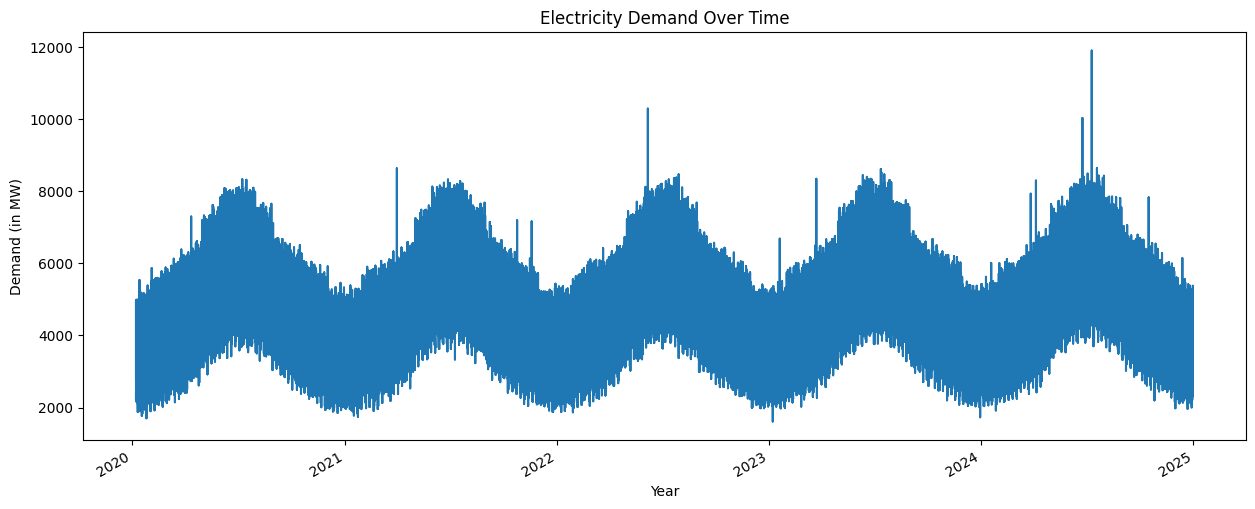

In [52]:
# Plot raw demand over time

data['Demand'].plot(figsize =(15,6), title = "Electricity Demand Over Time")
plt.xlabel("Year")                          # naming for x-axis
plt.ylabel("Demand (in MW)")                # naming for y-axis

plt.show()

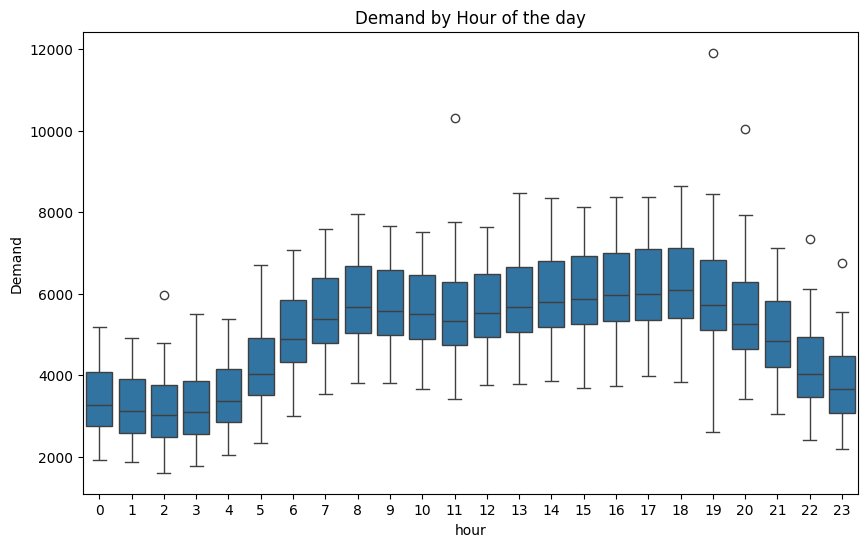

In [53]:
# Visualize demand by hour of day, using boxplot

plt.figure(figsize = (10,6))
sns.boxplot(data = data, x = 'hour', y = 'Demand')
plt.title("Demand by Hour of the day");

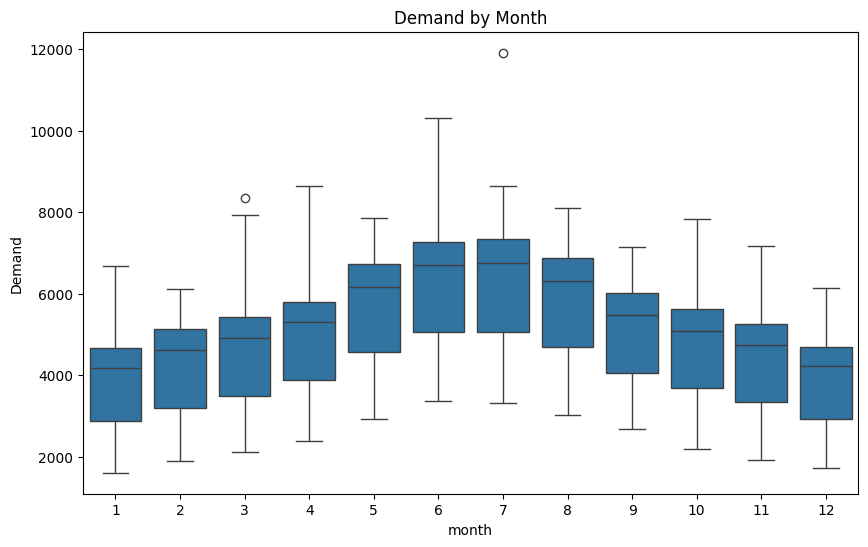

In [54]:
# Visualize demand by month, using boxplot

plt.figure(figsize=(10,6))
sns.boxplot(data = data, x = 'month', y = 'Demand')
plt.title("Demand by Month")
plt.show()

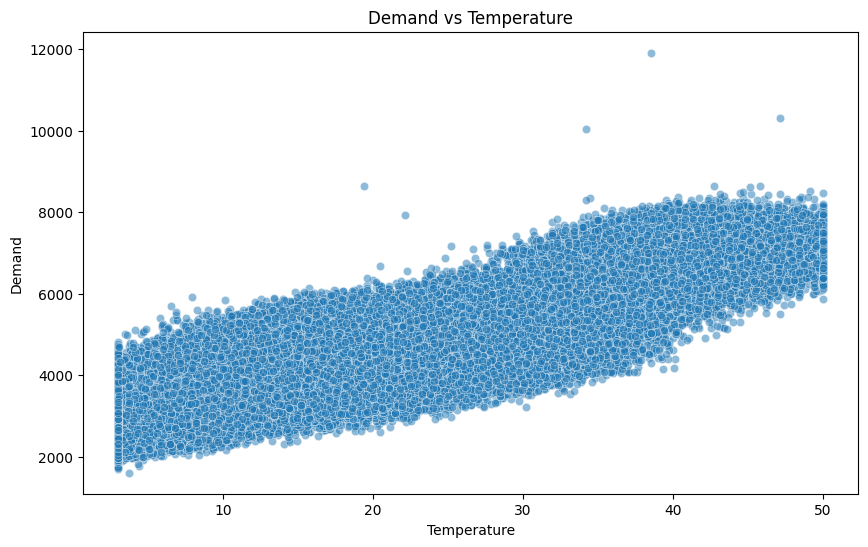

In [55]:
# Scatter plot of Demand vs. Temperature

plt.figure(figsize=(10,6))
sns.scatterplot(data = data, x = 'Temperature', y = 'Demand', alpha = 0.5)  #alpha - to adjust the tranparency of points
plt.title("Demand vs Temperature")
plt.show()

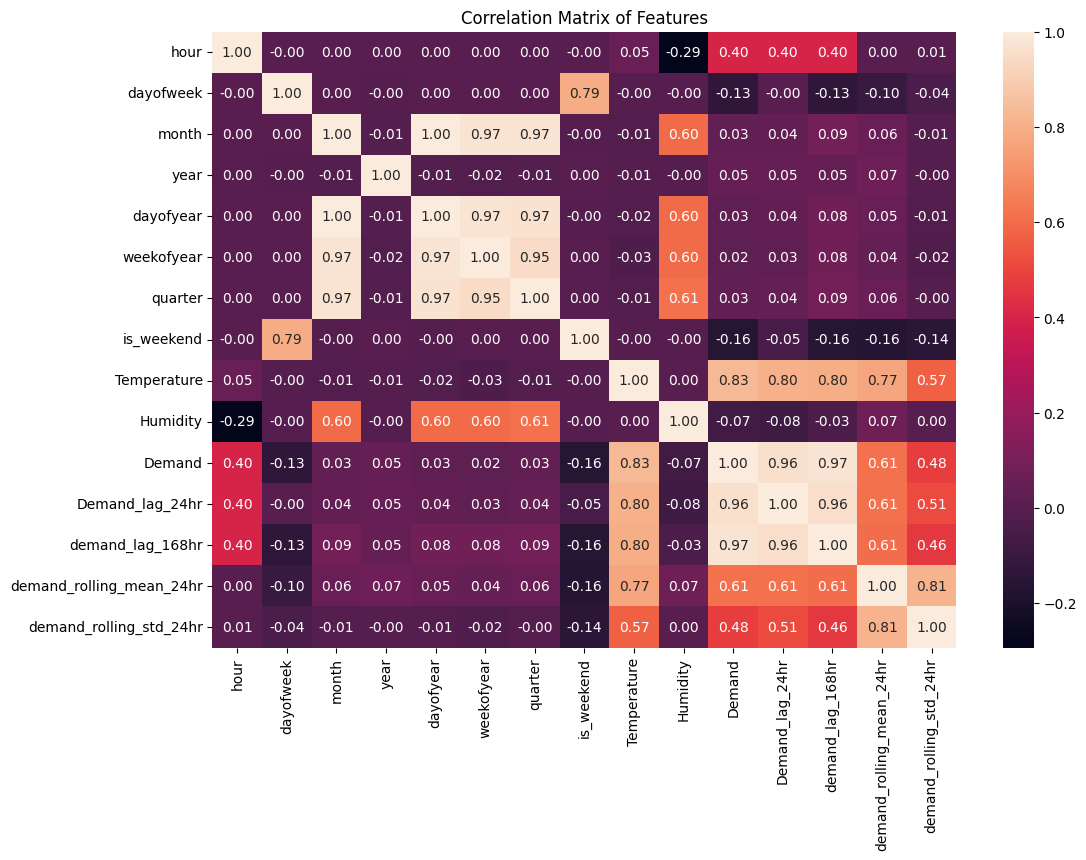

In [56]:
# Correlation Matrix and Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot = True, fmt=".2f") # anoot=True : to show the numbers , fmt : to adjust decimals
plt.title("Correlation Matrix of Features")
plt.show()

In [57]:
# Defining Target Variable (Y)

Y = data.Demand                         # target variable / dependent variable

In [59]:
print(Y)           # Target variable

Timestamp
2020-01-08    2363.060115
2020-01-08    2282.558766
2020-01-08    2193.324174
2020-01-08    2208.724679
2020-01-08    2402.611018
                 ...     
2024-12-31    4689.693109
2024-12-31    4331.249224
2024-12-31    4015.979957
2024-12-31    3353.241682
2024-12-31    3219.023339
Name: Demand, Length: 43676, dtype: float64


In [58]:
# Defining Features (X)

X = data.drop('Demand', axis=1)         # independent variables / features / predictors

In [60]:
X                    # Features

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2216.875986,2457.119872,3857.890516,1007.130968
2020-01-08,1,2,1,2020,8,2,1,0,4.433666,61.209727,2400.102433,2269.904712,3852.992863,1014.785101
2020-01-08,2,2,1,2020,8,2,1,0,5.000529,63.868618,2493.107375,2215.640403,3840.501897,1033.916351
2020-01-08,3,2,1,2020,8,2,1,0,4.253477,44.603210,2241.451559,2174.232413,3839.138277,1036.136212
2020-01-08,4,2,1,2020,8,2,1,0,5.966044,85.921008,2406.161001,2472.453006,3838.990361,1036.349905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,3859.260701,3856.359014,4052.475170,977.565114


In [61]:
# Splitting the data into Training and Testing data

X_train = X.loc[ : '2023-12-31']                  # taking 80% of data as training data

In [62]:
X_train                                           # 80% of the training features data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,
2020-01-08,0,2,1,2020,8,2,1,0,3.000000,47.891592,2216.875986,2457.119872,3857.890516,1007.130968
2020-01-08,1,2,1,2020,8,2,1,0,4.433666,61.209727,2400.102433,2269.904712,3852.992863,1014.785101
2020-01-08,2,2,1,2020,8,2,1,0,5.000529,63.868618,2493.107375,2215.640403,3840.501897,1033.916351
2020-01-08,3,2,1,2020,8,2,1,0,4.253477,44.603210,2241.451559,2174.232413,3839.138277,1036.136212
2020-01-08,4,2,1,2020,8,2,1,0,5.966044,85.921008,2406.161001,2472.453006,3838.990361,1036.349905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31,19,6,12,2023,365,52,4,1,6.721774,46.627264,3894.908251,3840.654680,3597.790591,879.089476
2023-12-31,20,6,12,2023,365,52,4,1,7.557696,58.505012,3797.287793,4122.218903,3599.126925,879.430235
2023-12-31,21,6,12,2023,365,52,4,1,3.000000,48.001079,3280.602315,3307.887152,3604.785551,877.726873


In [63]:
Y_train = Y.loc[ : '2023-12-31' ]             # taking 80% of data as training data

In [64]:
Y_train                                       # 80% of the training target variable

,Demand
Timestamp,
2020-01-08,2363.060115
2020-01-08,2282.558766
2020-01-08,2193.324174
2020-01-08,2208.724679
2020-01-08,2402.611018
...,...
2023-12-31,4185.721624
2023-12-31,3829.359810
2023-12-31,3416.409325


In [65]:
X_test = X.loc[ '2024-01-01' : ]               # taking 20% of data as testing data

In [66]:
X_test                                         # 20% of the training features data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand_lag_24hr,demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,
2024-01-01,0,0,1,2024,1,1,1,0,3.000000,65.297046,2373.967493,2752.003113,3626.185642,856.204515
2024-01-01,1,0,1,2024,1,1,1,0,3.000000,69.068654,2328.972904,2419.747602,3640.380403,836.357296
2024-01-01,2,0,1,2024,1,1,1,0,3.000000,80.885372,1729.176090,2292.834087,3669.813854,776.458065
2024-01-01,3,0,1,2024,1,1,1,0,7.788675,66.501527,2257.337352,2507.704476,3685.801618,749.595470
2024-01-01,4,0,1,2024,1,1,1,0,6.607828,57.858109,2516.948873,2690.933257,3692.926651,738.736316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19,1,12,2024,366,1,4,0,3.956838,43.287161,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20,1,12,2024,366,1,4,0,3.118824,51.705756,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21,1,12,2024,366,1,4,0,3.000000,40.565916,3859.260701,3856.359014,4052.475170,977.565114


In [67]:
Y_test = Y.loc[ '2024-01-01' : ]                       # taking 20% of data as testing data

In [68]:
Y_test                                                 # 20% of the testing target variable

,Demand
Timestamp,
2024-01-01,2720.606072
2024-01-01,2669.647167
2024-01-01,2435.578924
2024-01-01,2641.043699
2024-01-01,2687.949643
...,...
2024-12-31,4689.693109
2024-12-31,4331.249224
2024-12-31,4015.979957


In [69]:
print(X_train.shape)
print(Y_train.shape)

(34892, 14)
(34892,)


In [70]:
print(X_test.shape)
print(Y_test.shape)

(8784, 14)
(8784,)


# XGBoost

XGBoost is a powerful algorithm for time-series forecasting, as it can handle non-linear data easily.

It can handle seasonality and trends in time-series data effectively.

In [71]:
from xgboost import XGBRegressor     # from XGBoost library we are importing XGBRegressor class

# from sklearn library importing two fundamental metrics to evaluate the performance of the model
from sklearn.metrics import mean_squared_error, mean_absolute_error

# from model_selection module of scikit-learn's library, import TimeSeriesSplit class
# TimeSeriesSplit class performs appropriate cross-validation when dealing with time series data
from sklearn.model_selection import TimeSeriesSplit

Bu bölümde modelleme için gerekli araçlar yükleniyor:

XGBRegressor: XGBoost kütüphanesinden regresyon (sayısal tahmin) problemlerini çözmek için kullanılan ana sınıf.

mean_squared_error ve mean_absolute_error: Modelin tahmin başarısını ölçmek için kullanılan metrikler (Hata kareler ortalaması ve mutlak hata ortalaması).

TimeSeriesSplit: Zaman serisi verilerine özel bir çapraz doğrulama (cross-validation) yöntemidir. Verinin kronolojik sırasını bozmadan test ve eğitim setlerine ayrılmasını sağlar.

In [72]:
# Initialize and train the model

model_xgb = XGBRegressor(n_estimators = 1000,
                         early_stopping_rounds = 50,
                         learning_rate = 0.01,
                         random_state = 42,
                         objective = 'reg:squarederror' )

model_xgb = XGBRegressor(...) satırı, modelin "beynini" yapılandırıyor:

n_estimators = 1000: Modelin toplamda oluşturabileceği maksimum ağaç (boosting turu) sayısıdır.

early_stopping_rounds = 50: Modelin aşırı öğrenmesini (overfitting) engellemek için kullanılır. Eğer doğrulama setindeki performans 50 tur boyunca iyileşmezse eğitimi durdurur.

learning_rate = 0.01: Her bir ağacın modele olan katkısını sınırlar. Küçük bir öğrenme oranı, modelin daha yavaş ama daha kararlı öğrenmesini sağlar.

random_state = 42: Kod her çalıştırıldığında aynı rastgele sonuçların üretilmesini sağlar (tekrarlanabilirlik).

objective = 'reg:squarederror': Modelin neyi minimize etmeye çalışacağını belirler. Burada amaç, tahmin edilen değer ile gerçek değer arasındaki kare farkını (hatayı) en aza indirmektir.

In short :

The XGBRegressor initialization creates a model that will train for up to 1000 boosting rounds (trees) but will stop early if performance on a validation set doesn't improve for 50 consecutive rounds.

Each tree's contribution is scaled down by a learning rate of 0.01 to prevent overfitting.

This model is designed to minimize the squared error for regression tasks.

3. Neden Zaman Serisinde XGBoost?

XGBoost şu avantajları sunar:

Doğrusal olmayan (non-linear) verileri kolayca işleyebilir.

Verideki mevsimsellik (seasonality) ve trendleri etkili bir şekilde yakalayabilir.

In [73]:
# training the model

model_xgb.fit(X_train, Y_train, eval_set = [(X_train, Y_train), (X_test, Y_test)], verbose = False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

fit: Modeli eğitme komutudur. Model, X_train (girdi özellikleri) ve Y_train (hedef değerler) arasındaki ilişkiyi öğrenir.

eval_set: Eğitim sırasında modelin performansını hem eğitim hem de test setinde izlemesini sağlar. Bu, modelin "ezberleyip ezberlemediğini" (overfitting) kontrol etmek için kritiktir.

verbose = False: Eğitim sırasındaki her bir adımın (turun) çıktılarını ekrana yazdırmaz, süreci sessizce yürütür.

In [74]:
# Make predictions

predictions_xgb = model_xgb.predict(X_test)

In [75]:
# Evaluating the model

rmse_xgb = np.sqrt(mean_squared_error(Y_test, predictions_xgb))

mae_xgb = mean_absolute_error(Y_test, predictions_xgb )

In [76]:
print('XGBoost RMSE:',  rmse_xgb)
print('XGBoost MAE:' ,  mae_xgb)

XGBoost RMSE: 175.22716387271916
XGBoost MAE: 123.47612356015286


Model eğitildikten sonra, görmediği veriler (X_test) üzerinde ne kadar başarılı olduğu ölçülür:

predict(X_test): Eğitilen modeli kullanarak test verileri için tahminler üretir.

RMSE (Root Mean Squared Error): Hataların karesinin ortalamasının kareköküdür. Büyük hatalara daha fazla ceza keser.

MAE (Mean Absolute Error): Tahminler ile gerçek değerler arasındaki mutlak farkın ortalamasıdır.

Sonuçlar: Görseldeki verilere göre modelin RMSE değeri ~174.82, MAE değeri ise ~123.47 çıkmıştır. Bu değerler ne kadar düşükse model o kadar başarılıdır.

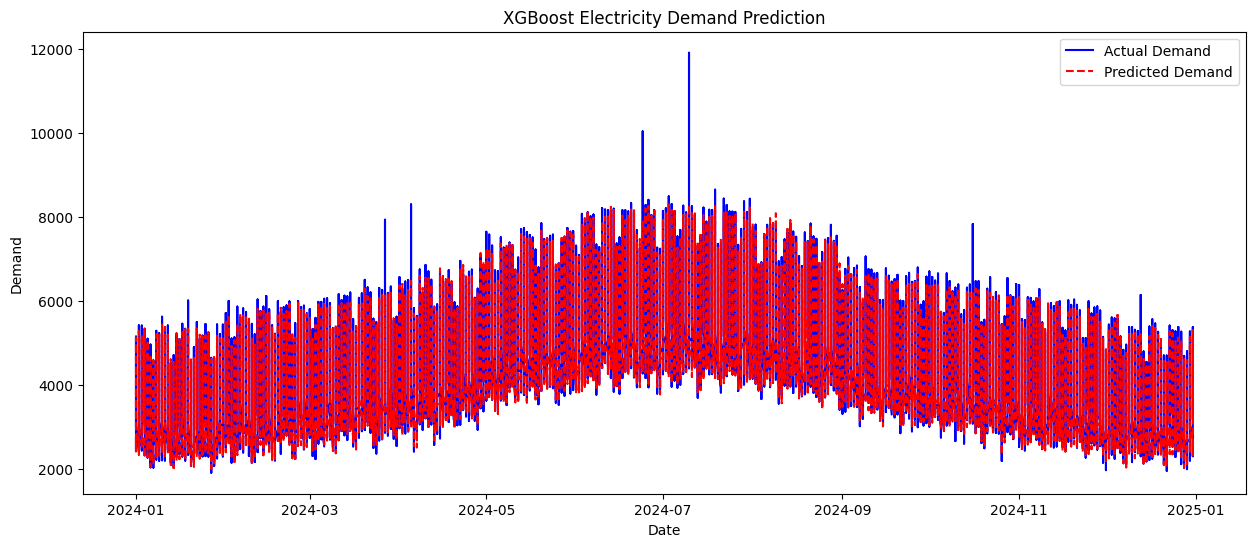

In [77]:
# Visulaize the Predictions

plt.figure(figsize = (15,6))
plt.plot(Y_test.index, Y_test, label = 'Actual Demand', color = 'Blue')
plt.plot(Y_test.index, predictions_xgb, label = 'Predicted Demand', color = 'Red', linestyle='--')
plt.title('XGBoost Electricity Demand Prediction')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()

plt.show()

Mavi Çizgi: Gerçek elektrik talebi (Actual Demand).

Kırmızı Kesikli Çizgi: Modelin tahmini (Predicted Demand).

Grafiğe bakıldığında kırmızı çizgilerin mavi çizgileri çok yakından takip ettiği, yani modelin genel trendi ve mevsimselliği başarıyla yakaladığı görülmektedir.

In [82]:
# save the model

import joblib

joblib.dump(model_xgb, 'electricity_xgb_prediction_model.pkl')

['electricity_xgb_prediction_model.pkl']

In [84]:
# load and Use:

loaded_model = joblib.load('electricity_xgb_prediction_model.pkl')

# future_predictions = loaded_model.predict(X_future)

In [85]:
loaded_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

Modeli her seferinde yeniden eğitmek yerine diske kaydedip ihtiyacınız olduğunda kullanabilirsiniz:

joblib.dump: Eğitilmiş model_xgb nesnesini .pkl uzantılı bir dosya olarak kaydeder.

joblib.load: Kaydedilen bu dosyayı geri yükler. Böylece loaded_model.predict(X_future) diyerek yeni, gelecekteki veriler için anında tahmin alabilirsiniz.